In [1]:
from google.colab import files
uploaded = files.upload()

Saving project.zip to project (1).zip


In [2]:
import zipfile, os

zip_path = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/")

print(os.listdir("/content/"))

['.config', 'project.zip', '__MACOSX', 'project (1).zip', 'project', 'sample_data']


In [3]:
%cd /content/project
!ls


/content/project
configs  main.py  model  training  utils


In [4]:
!pip install kagglehub torch torchvision scikit-learn matplotlib

In [6]:
!grep chest_xray /content/project/training/train.py

    base_path = os.path.join(data_path, "chest_xray")


In [7]:
!python main.py

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Dataset Path: /kaggle/input/chest-xray-pneumonia

--- CNN Baseline ---
Device: cuda
DATA PATH: /kaggle/input/chest-xray-pneumonia/chest_xray
Epoch 1: TrainLoss=0.3501, ValLoss=0.5455, Acc=0.6875, F1=0.6154, AUC=0.8125
Epoch 2: TrainLoss=0.2514, ValLoss=0.5238, Acc=0.6875, F1=0.7059, AUC=0.7812
Epoch 3: TrainLoss=0.2271, ValLoss=0.5151, Acc=0.7500, F1=0.8000, AUC=0.9531
Epoch 4: TrainLoss=0.2002, ValLoss=2.6082, Acc=0.6250, F1=0.7273, AUC=0.6719
Epoch 5: TrainLoss=0.1813, ValLoss=0.5588, Acc=0.7500, F1=0.8000, AUC=0.8594
Epoch 6: TrainLoss=0.1767, ValLoss=0.6617, Acc=0.7500, F1=0.8000, AUC=0.8438
Epoch 7: TrainLoss=0.1573, ValLoss=0.4261, Acc=0.6875, F1=0.7059, AUC=0.9062
Epoch 8: TrainLoss=0.1498, ValLoss=1.1247, Acc=0.6250, F1=0.7273, AUC=0.8594
Epoch 9: TrainLoss=0.1531, ValLoss=2.7946, Acc=0.5000, F1=0.6667, AUC=0.9531
Epoch 10: TrainLoss=0.1469, ValLoss=0.6574, Acc=0.6875, F1=0.7368, AUC=0.7656
Epoch 11: Tra

In [8]:
%cd /content/project
!ls

/content/project
accuracy_curve.png  configs	    main.py  training
best_model.pth	    loss_curve.png  model    utils


In [9]:
# Ablation - "NO ROUTING" version

%%writefile model/lhtm_no_routing.py
import torch.nn as nn
from model.image_embeddings import ImageToTokens
from model.encoder_block import EncoderBlock

class LHTMNoRouting(nn.Module):
    def __init__(self, config):
        super().__init__()

        m = config["model"]
        i = config["image"]

        self.img_to_tokens = ImageToTokens(
            i["img_size"],
            i["patch_size"],
            i["in_channels"],
            m["d_model"],
            i["use_class_token"],
            i["use_pos_encoding"]
        )

        # SAME encoder but we will disable routing via flag
        self.layers = nn.ModuleList([
            EncoderBlock(
                m["d_model"],
                m["num_heads"],
                m["window_size"],
                m["ff_dim"],
                m["num_routing_tokens"],
                m["dropout"]
            )
            for _ in range(m["num_layers"])
        ])

        self.norm = nn.LayerNorm(m["d_model"])
        self.head = nn.Linear(m["d_model"], i["num_classes"])

        self.use_class_token = i["use_class_token"]

    def forward(self, x):
        x = self.img_to_tokens(x)

        for layer in self.layers:
            # manually skip routing
            x = x + layer.local_attn(layer.norm1(x))
            x = x + layer.ff(layer.norm3(x))

        x = self.norm(x)

        if self.use_class_token:
            x = x[:, 0]
        else:
            x = x.mean(dim=1)

        return self.head(x)

Writing model/lhtm_no_routing.py


In [10]:
# "NO LOCAL ATTENTION" version

%%writefile model/lhtm_no_local.py
import torch.nn as nn
from model.image_embeddings import ImageToTokens
from model.encoder_block import EncoderBlock

class LHTMNoLocal(nn.Module):
    def __init__(self, config):
        super().__init__()

        m = config["model"]
        i = config["image"]

        self.img_to_tokens = ImageToTokens(
            i["img_size"],
            i["patch_size"],
            i["in_channels"],
            m["d_model"],
            i["use_class_token"],
            i["use_pos_encoding"]
        )

        self.layers = nn.ModuleList([
            EncoderBlock(
                m["d_model"],
                m["num_heads"],
                m["window_size"],
                m["ff_dim"],
                m["num_routing_tokens"],
                m["dropout"]
            )
            for _ in range(m["num_layers"])
        ])

        self.norm = nn.LayerNorm(m["d_model"])
        self.head = nn.Linear(m["d_model"], i["num_classes"])

        self.use_class_token = i["use_class_token"]

    def forward(self, x):
        x = self.img_to_tokens(x)

        for layer in self.layers:
            # skip local attention
            x = x + layer.routing(layer.norm2(x))
            x = x + layer.ff(layer.norm3(x))

        x = self.norm(x)

        if self.use_class_token:
            x = x[:, 0]
        else:
            x = x.mean(dim=1)

        return self.head(x)

Writing model/lhtm_no_local.py


In [11]:
# Run file for Ablation

%%writefile ablation_run.py
import yaml
import kagglehub

from training.train import train
from model.lhtm_no_routing import LHTMNoRouting
from model.lhtm_no_local import LHTMNoLocal

# download dataset
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

with open("configs/base.yaml") as f:
    config = yaml.safe_load(f)

config["image"]["in_channels"] = 3
config["image"]["num_classes"] = 2
config["image"]["img_size"] = 224

print("\n--- LHTM WITHOUT ROUTING ---")
model1 = LHTMNoRouting(config)
train(model1, config, "chest_xray", path)

print("\n--- LHTM WITHOUT LOCAL ATTENTION ---")
model2 = LHTMNoLocal(config)
train(model2, config, "chest_xray", path)

Writing ablation_run.py


In [12]:
# Running Ablation

!python ablation_run.py

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.

--- LHTM WITHOUT ROUTING ---
Device: cuda
DATA PATH: /kaggle/input/chest-xray-pneumonia/chest_xray
Epoch 1: TrainLoss=0.4157, ValLoss=0.8188, Acc=0.6250, F1=0.6667, AUC=0.7656
Epoch 2: TrainLoss=0.3007, ValLoss=0.9175, Acc=0.5625, F1=0.6667, AUC=0.8906
Epoch 3: TrainLoss=0.2772, ValLoss=0.8437, Acc=0.5625, F1=0.6667, AUC=0.8281
Epoch 4: TrainLoss=0.2610, ValLoss=0.9991, Acc=0.5000, F1=0.6364, AUC=0.8281
Epoch 5: TrainLoss=0.2358, ValLoss=0.7754, Acc=0.5625, F1=0.6667, AUC=0.8594
Epoch 6: TrainLoss=0.2293, ValLoss=0.7664, Acc=0.6250, F1=0.7000, AUC=0.8438
Epoch 7: TrainLoss=0.2311, ValLoss=0.6144, Acc=0.6875, F1=0.7368, AUC=0.8594
Epoch 8: TrainLoss=0.2179, ValLoss=0.6609, Acc=0.7500, F1=0.7778, AUC=0.8125
Epoch 9: TrainLoss=0.2039, ValLoss=1.1162, Acc=0.5625, F1=0.6667, AUC=0.8438
Epoch 10: TrainLoss=0.2083, ValLoss=0.5419, Acc=0.8125, F1=0.8235, AUC=0.7812
Epoch 11: TrainLoss=0.2051, ValLoss=0.7262, Acc=0.5625

/content/project
Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
DATA PATH: /kaggle/input/chest-xray-pneumonia/chest_xray

===== FINAL METRICS =====
Accuracy : 0.6619
Precision: 0.6494
Recall   : 0.9974
F1 Score : 0.7867
ROC-AUC  : 0.8745


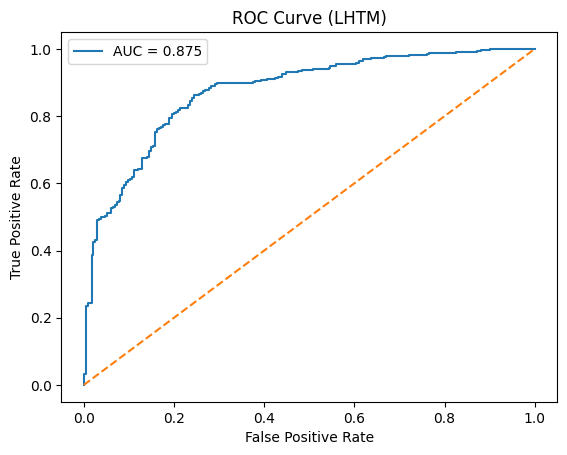

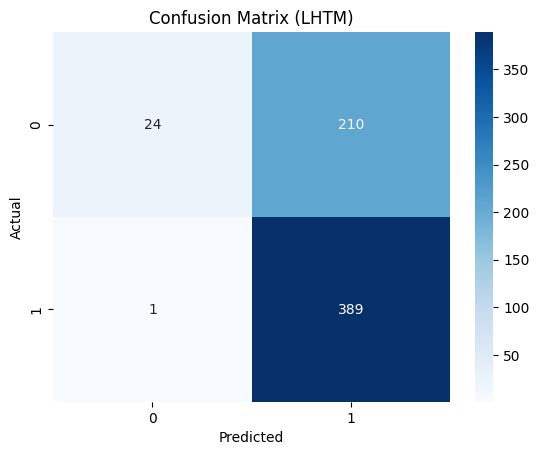

In [13]:
%cd /content/project

import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    roc_curve,
    roc_auc_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)

from training.train import get_dataloader
from model.lhtm_image import LHTMImageClassifier
import yaml
import kagglehub

# ----------------------------
# Load config
# ----------------------------
with open("configs/base.yaml") as f:
    config = yaml.safe_load(f)

config["image"]["in_channels"] = 3
config["image"]["num_classes"] = 2
config["image"]["img_size"] = 224

# ----------------------------
# Load dataset
# ----------------------------
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")
_, _, test_loader = get_dataloader(path, config["training"]["batch_size"])

# ----------------------------
# Load best model
# ----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = LHTMImageClassifier(config)
model.load_state_dict(torch.load("best_model.pth", map_location=device))
model.to(device)
model.eval()

# ----------------------------
# Evaluation
# ----------------------------
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for x, y in test_loader:
        x, y = x.to(device), y.to(device)
        out = model(x)

        probs = torch.softmax(out, dim=1)[:, 1]
        _, pred = out.max(1)

        all_probs.extend(probs.cpu().numpy())
        all_preds.extend(pred.cpu().numpy())
        all_labels.extend(y.cpu().numpy())

all_labels = np.array(all_labels)
all_preds = np.array(all_preds)
all_probs = np.array(all_probs)

# ----------------------------
# Metrics
# ----------------------------
accuracy = (all_preds == all_labels).mean()
precision = precision_score(all_labels, all_preds)
recall = recall_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds)
auc = roc_auc_score(all_labels, all_probs)

print("\n===== FINAL METRICS =====")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {auc:.4f}")

# ----------------------------
# ROC Curve
# ----------------------------
fpr, tpr, _ = roc_curve(all_labels, all_probs)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (LHTM)")
plt.legend()
plt.savefig("roc_lhtm.png")
plt.show()

# ----------------------------
# Confusion Matrix
# ----------------------------
cm = confusion_matrix(all_labels, all_preds)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (LHTM)")
plt.savefig("cm_lhtm.png")
plt.show()